In [86]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.optim as optim
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

# Autoencoders

In [2]:
class Encoder(nn.Module):
    def __init__(self,latent_dim = 128):
        super(Encoder,self).__init__()
        self.layer = nn.Linear(128*128,512)
        self.mean_x = nn.Linear(512,latent_dim)
        self.logvar_x = nn.Linear(512,latent_dim)
        self.relu = nn.ReLU()
    def forward(self,X):  # Shape = (b,1,128,128)
        X = X.squeeze(1).reshape(X.shape[0],-1)
        out = self.layer(X) # b,512
        out = self.relu(out)
        mean_x = self.mean_x(out)
        logvar_x = self.logvar_x(out)
        return mean_x,logvar_x

## Encoder Output are the set of latent vec with mean and logvar(128 in this example)

In [3]:
trash_encoder = Encoder()
anh_flatten = torch.rand(100,1,128,128)
trash_encoder(anh_flatten)[0].shape

torch.Size([100, 128])

In [4]:
class Decoder(nn.Module):
    def __init__(self,latent_dim = 128):
        super(Decoder,self).__init__()
        self.layer = nn.Linear(latent_dim,512)
        self.output = nn.Linear(512,128*128)
    def forward(self,X):
        out = self.layer(X)
        return self.output(out)

In [5]:
trash_decoder = Decoder()
trash_z = torch.rand(100,128)
trash_decoder(trash_z).shape

torch.Size([100, 16384])

# AE model

In [6]:
torch.exp(torch.tensor(-2))

tensor(0.1353)

In [7]:
class AE(nn.Module):
    def __init__(self,latent_dim):
        super(AE,self).__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)
    def forward(self,X):
        mean, logvar = self.encoder(X) # (b,latent_dim)
        Z = mean + torch.exp(logvar) * torch.randn_like(mean)
        return self.decoder(Z)

In [8]:
latent_dim = 128
AE_lr = 2e-4
AE_betas = [0.5,0.999]
AE_model = AE(128)
AE_optimizer = optim.AdamW(AE_model.parameters(),lr = AE_lr,betas = AE_betas)

# Dataset 

In [9]:
transform = transforms.Compose([
    transforms.Resize([128,128]),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
train_dataset = datasets.MNIST(
    root='./data', 
    train=True, 
    transform=transform, 
    download=True
)
test_dataset = datasets.MNIST(
    root='./data', 
    train=False, 
    transform=transform, 
    download=True
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 86.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 26.4MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 58.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.1MB/s]


In [10]:
AE_dataloader = DataLoader(train_dataset,
                          batch_size = 32,
                           shuffle = True,
                           drop_last = False)

ảnh đen trắng nhé

In [11]:
mau = next(iter(AE_dataloader))
mau[0].shape,mau[1]

(torch.Size([32, 1, 128, 128]),
 tensor([0, 0, 5, 2, 0, 3, 4, 7, 3, 8, 4, 5, 7, 2, 7, 7, 6, 0, 7, 9, 7, 6, 6, 4,
         9, 1, 8, 6, 6, 3, 6, 1]))

## AE Training

In [12]:
print(AE_model)

AE(
  (encoder): Encoder(
    (layer): Linear(in_features=16384, out_features=512, bias=True)
    (mean_x): Linear(in_features=512, out_features=128, bias=True)
    (logvar_x): Linear(in_features=512, out_features=128, bias=True)
    (relu): ReLU()
  )
  (decoder): Decoder(
    (layer): Linear(in_features=128, out_features=512, bias=True)
    (output): Linear(in_features=512, out_features=16384, bias=True)
  )
)


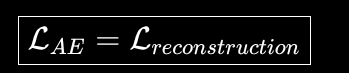

In [13]:
device = device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
AE_model.to(device)
AE_loss = nn.MSELoss()
def AE_train():
    for e in range(10):
        avg_loss = 0
        for inputs, _ in AE_dataloader:
            inputs = inputs.to(device)
            targets = inputs.squeeze(1).reshape(inputs.shape[0],-1)
            
            AE_optimizer.zero_grad()
            outputs = AE_model(inputs)
            loss = AE_loss(outputs,targets)
            loss.backward()
            AE_optimizer.step()

            avg_loss += loss.item() / len(inputs)
        print(f"Loss at epoch {e + 1}: {avg_loss / len(AE_dataloader)}")
            

In [14]:
AE_train()

Loss at epoch 1: 0.0039060634572058916
Loss at epoch 2: 0.0018632984074453513
Loss at epoch 3: 0.0012972732267342508
Loss at epoch 4: 0.001215001308421294
Loss at epoch 5: 0.0013357509935895602
Loss at epoch 6: 0.0011808106100186706
Loss at epoch 7: 0.0011972861415706574
Loss at epoch 8: 0.0013110500739887357
Loss at epoch 9: 0.0011485929160689314
Loss at epoch 10: 0.0011780674954876304


In [15]:
def AE_inference(img_dir):
    AE_model.eval()
    image = Image.open(img_dir).convert("L")
    input_tensor = transform(image).unsqueeze(0).to(device) # 1,1,128,128
    with torch.no_grad():
        output = AE_model(input_tensor)

    input_image = (
        input_tensor[0][0]
        .detach()
        .cpu()
        .clamp(0, 1)
        .numpy()
    )
    output_image = (
        output[0]
        .reshape(128,128)
        .detach()
        .cpu()
        .clamp(0, 1)
        .numpy()
    )
    # show img
    plt.subplot(1, 2, 1)
    plt.imshow(input_image, cmap="gray" if input_image.ndim == 2 else None)
    plt.title("Input image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(output_image, cmap="gray" if output_image.ndim == 2 else None)
    plt.title("Reconstructed image")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

### Prepare test data

In [16]:
import os
mnist_test = datasets.MNIST(
    root="/kaggle/working/data",
    train=False,
    download=True
)

for index in range(10):
    image, label = mnist_test[index]
    name = str(index) + ".png"
    img_path = os.path.join("/kaggle/working",name)
    image.save(img_path)

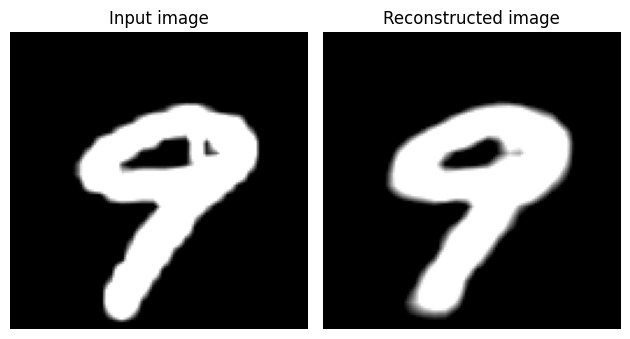

In [17]:
img_dir = "/kaggle/working/9.png"
AE_inference(img_dir)

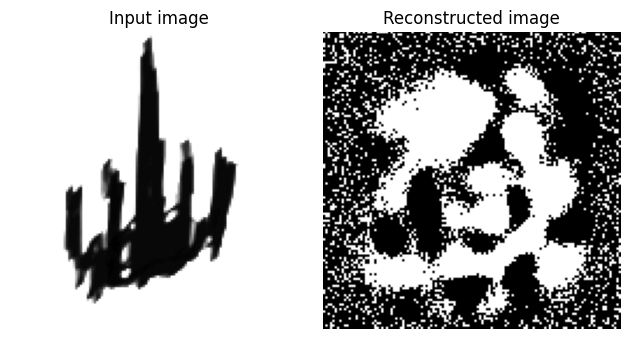

In [18]:
img_dir_hehe = "/kaggle/input/datasets/mrrobotbamboo/inference-ae/Screenshot From 2026-06-21 15-13-25.png"
AE_inference(img_dir_hehe)

# VAE

!image.png

In [37]:
# Input cua encoder la (1,?,128 * 128)
class Encoder(nn.Module):
    def __init__(self,hidden_dim = 400,latent_dim = 128):
        super(Encoder,self).__init__()
        self.model = nn.Sequential(
            nn.Linear(128*128,hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim,hidden_dim),
            nn.Tanh()
        )
        self.mean = nn.Linear(hidden_dim,latent_dim)
        self.logvar = nn.Linear(hidden_dim,latent_dim)
    def forward(self,X):
        output = self.model(X)
        mean = self.mean(output)
        logvar = self.logvar(output)
        return mean,logvar
# input cua decoder la (1,?,latent_dim)
class Decoder(nn.Module):
    def __init__(self,hidden_dim = 400,latent_dim = 128):
        super(Decoder,self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim,hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim,hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim,128 * 128),
        )
    def forward(self,X):
        output = self.model(X)
        return output

In [38]:
trash_input = torch.rand(1,1,128*128)
trash_encoder = Encoder()
print(trash_encoder(trash_input)[0].shape)

trash_input_2 = torch.rand(1,1,128)
trash_decoder = Decoder()
trash_decoder(trash_input_2).shape


torch.Size([1, 1, 128])


torch.Size([1, 1, 16384])

In [79]:
class VAE(nn.Module):
    def __init__(self,hidden_dim = 400,latent_dim = 128):
        super(VAE,self).__init__()
        self.encoder = Encoder(hidden_dim,latent_dim)
        self.decoder = Decoder(hidden_dim,latent_dim)

    def forward(self,X):
        b,layer,_ ,_ = X.shape
        X = X.squeeze(1).reshape(b,-1)
        mean,logvar = self.encoder(X)
        output = mean + torch.exp(logvar * 0.5) * torch.randn_like(mean)
        recon_img = self.decoder(output)
        return recon_img,mean,logvar

    
    def inference(self,num_samples=1):
        self.eval()
        device = next(self.parameters()).device
        with torch.no_grad():
            z = torch.randn(
                num_samples,
                128,
                device=device
            )
            return self.decoder(z).reshape(num_samples,-1,128,128)

In [80]:
trash_img = torch.rand(10,1,128,128)
trash_VAE = VAE()
trash_VAE(trash_img)[0].shape

torch.Size([10, 16384])

In [81]:
trash_VAE.inference().shape

torch.Size([1, 1, 128, 128])

# Loss VAE

In [122]:
def VAE_Loss(img,recon_img,mean,logvar,beta = 1.0):
    flatten_img = img.reshape(recon_img.shape)
    batch_size = img.shape[0]
    recon_loss = F.mse_loss(recon_img,flatten_img,reduction="sum")
    KL_loss = -0.5 * torch.sum(1 + logvar - mean.pow(2) - torch.exp(logvar))
    recon_loss = recon_loss / batch_size
    KL_loss = KL_loss / batch_size
    return recon_loss + beta * KL_loss

In [132]:
VAE_dataloader = DataLoader(train_dataset,
                          batch_size = 32,
                           shuffle = True,
                           drop_last = False)
VAE_model = VAE()
LR = 1e-3
BETAS = [0.9,0.999]
optimizer = optim.AdamW(VAE_model.parameters(),lr = LR,betas = BETAS)
EPOCHS = 20
VAE_model.to(device)

VAE(
  (encoder): Encoder(
    (model): Sequential(
      (0): Linear(in_features=16384, out_features=400, bias=True)
      (1): Tanh()
      (2): Linear(in_features=400, out_features=400, bias=True)
      (3): Tanh()
    )
    (mean): Linear(in_features=400, out_features=128, bias=True)
    (logvar): Linear(in_features=400, out_features=128, bias=True)
  )
  (decoder): Decoder(
    (model): Sequential(
      (0): Linear(in_features=128, out_features=400, bias=True)
      (1): Tanh()
      (2): Linear(in_features=400, out_features=400, bias=True)
      (3): Tanh()
      (4): Linear(in_features=400, out_features=16384, bias=True)
    )
  )
)

In [124]:
def train(model):
    for e in range(EPOCHS):
        avg_loss = 0
        for (img, _ ) in tqdm(VAE_dataloader):
            img = img.to(device)
            b_size = img.shape[0]
            recon_img,mean,logvar = model(img)
            optimizer.zero_grad()
            loss = VAE_Loss(img,recon_img,mean,logvar)
            loss.backward()
            optimizer.step()
            avg_loss += loss.item()
        print(f"Loss at epoch {e + 1} : {avg_loss / len(VAE_dataloader)}")
        

In [133]:
train(VAE_model)

100%|██████████| 1875/1875 [00:36<00:00, 51.11it/s]


Loss at epoch 1 : 5474.928351302084


100%|██████████| 1875/1875 [00:36<00:00, 51.65it/s]


Loss at epoch 2 : 4142.268851302083


100%|██████████| 1875/1875 [00:36<00:00, 51.26it/s]


...

Loss at epoch 18 : 2494.953650130208


100%|██████████| 1875/1875 [00:36<00:00, 51.86it/s]


Loss at epoch 19 : 2460.9182846354165


100%|██████████| 1875/1875 [00:35<00:00, 52.10it/s]

Loss at epoch 20 : 2432.3186779296875


In [134]:
def show_img():
    recon_img = VAE_model.inference()
    numpy_img = (recon_img
        .reshape(128,128)
        .detach()
        .cpu()
        .clamp(0, 1)
        .numpy()
        )
    plt.plot(pigsize = (2,2))
    plt.imshow(numpy_img,cmap = "gray")
    plt.title("Inference_Image")
    plt.axis("off")
    plt.show()

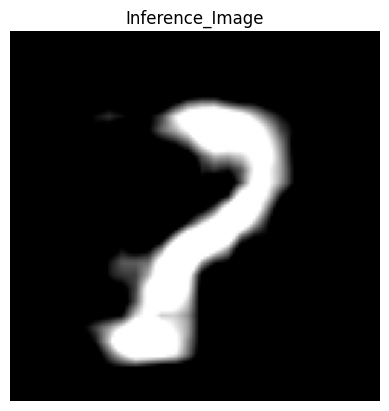

In [141]:
show_img()